<a href="https://colab.research.google.com/github/ramesesbarria/Assignment_1_Data_Analytics/blob/main/CS5101_NLP_Assignment_Analyzing_News_Articles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS5101 Natural Language Processing  
## Individual Programming Assignment  
### Option 1: Text Preprocessing and Linguistic Analysis  
### Title: Analyzing News Articles Using Text Preprocessing and Linguistic Analysis

**Student Name:** Rameses Luis Barria  
**Course:** CS5101 Natural Language Processing  
**Semester:** 2nd Semester, 2025–2026  

## Introduction

This project analyzes a dataset of news articles using basic Natural Language Processing techniques. The goal is to preprocess the text and perform linguistic analysis using spaCy. The notebook includes tokenization, stopword removal, lemmatization, part-of-speech tagging, noun and verb frequency counting, visualization, and summary statistics.

This project demonstrates how NLP can be used to understand the structure and content of news articles.

In [46]:
!pip install -q spacy datasets pandas matplotlib
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 49.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [47]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter

In [48]:
nlp = spacy.load("en_core_web_sm")

In [49]:
dataset = load_dataset("ag_news")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [50]:
# Convert the training dataset into a pandas DataFrame
df = pd.DataFrame(dataset["train"])

# Show the first few rows
df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [51]:
label_names = dataset["train"].features["label"].names

df["category"] = df["label"].apply(lambda x: label_names[x])

df.head()

,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [52]:
# Use 300 articles for faster processing
sample_df = df.sample(n=300, random_state=42).reset_index(drop=True)

sample_df.head()

,text,label,category
0,"BBC set for major shake-up, claims newspaper L...",2,Business
1,Marsh averts cash crunch Embattled insurance b...,2,Business
2,"Jeter, Yankees Look to Take Control (AP) AP - ...",1,Sports
3,Flying the Sun to Safety When the Genesis caps...,3,Sci/Tech
4,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,2,Business


In [53]:
for i in range(5):
    print("Article", i + 1)
    print("Category:", sample_df.loc[i, "category"])
    print(sample_df.loc[i, "text"])
    print("-" * 80)

Article 1
Category: Business
BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, The Times newspaper in London said on Monday.
--------------------------------------------------------------------------------
Article 2
Category: Business
Marsh averts cash crunch Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to credit. NEW YORK (Reuters) - Marsh  amp; McLennan Cos.
--------------------------------------------------------------------------------
Article 3
Category: Sports
Jeter, Yankees Look to Take Control (AP) AP - Derek Jeter turned a season that started with a terrible slump into one of the best in his accomplished 10-year career.
--------------------------------------------------------------------------------
Article 4
Category: Sci/Tech
Flying the Su

## Text Preprocessing

Text preprocessing is an important step in Natural Language Processing. In this project, the text is processed using spaCy.

The preprocessing steps include:

1. **Tokenization** - splitting text into individual words or tokens.
2. **Stopword Removal** - removing common words such as "the", "is", "and", and "of".
3. **Lemmatization** - converting words into their base form, such as "running" into "run".
4. **Part-of-Speech Tagging** - identifying the grammatical role of each word, such as noun, verb, adjective, or adverb.

In [54]:
def preprocess_text(text):
    """
    This function processes a text article using spaCy.

    It returns:
    - tokens
    - filtered tokens after stopword removal
    - lemmas
    - nouns
    - verbs
    - POS tags
    """

    doc = nlp(text)

    tokens = []
    filtered_tokens = []
    lemmas = []
    nouns = []
    verbs = []
    pos_tags = []

    for token in doc:
        # Basic tokenization
        tokens.append(token.text)

        # Remove stopwords, punctuation, spaces, and non-alphabetic tokens
        if not token.is_stop and not token.is_punct and not token.is_space and token.is_alpha:
            filtered_tokens.append(token.text.lower())
            lemmas.append(token.lemma_.lower())

            # POS tagging
            pos_tags.append((token.text, token.pos_))

            # Collect nouns
            if token.pos_ == "NOUN":
                nouns.append(token.lemma_.lower())

            # Collect verbs
            if token.pos_ == "VERB":
                verbs.append(token.lemma_.lower())

    return {
        "tokens": tokens,
        "filtered_tokens": filtered_tokens,
        "lemmas": lemmas,
        "nouns": nouns,
        "verbs": verbs,
        "pos_tags": pos_tags
    }

In [55]:
sample_text = sample_df.loc[0, "text"]

result = preprocess_text(sample_text)

print("Original Text:")
print(sample_text)

print("\nTokens:")
print(result["tokens"])

print("\nFiltered Tokens After Stopword Removal:")
print(result["filtered_tokens"])

print("\nLemmas:")
print(result["lemmas"])

print("\nPOS Tags:")
print(result["pos_tags"])

print("\nNouns:")
print(result["nouns"])

print("\nVerbs:")
print(result["verbs"])

Original Text:
BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, The Times newspaper in London said on Monday.

Tokens:
['BBC', 'set', 'for', 'major', 'shake', '-', 'up', ',', 'claims', 'newspaper', 'London', '-', 'The', 'British', 'Broadcasting', 'Corporation', ',', 'the', 'world', '#', '39;s', 'biggest', 'public', 'broadcaster', ',', 'is', 'to', 'cut', 'almost', 'a', 'quarter', 'of', 'its', '28', '000', '-', 'strong', 'workforce', ',', 'in', 'the', 'biggest', 'shake', '-', 'up', 'in', 'its', '82', '-', 'year', 'history', ',', 'The', 'Times', 'newspaper', 'in', 'London', 'said', 'on', 'Monday', '.']

Filtered Tokens After Stopword Removal:
['bbc', 'set', 'major', 'shake', 'claims', 'newspaper', 'london', 'british', 'broadcasting', 'corporation', 'world', 'biggest', 'public', 'broadcaster', 'cut'

## Applying NLP Processing to All Articles

After testing the preprocessing function on one article, the same function is applied to all sampled news articles. This allows the project to collect nouns, verbs, lemmas, tokens, and POS tags from the whole dataset.

In [56]:
all_tokens = []
all_filtered_tokens = []
all_lemmas = []
all_nouns = []
all_verbs = []
all_pos_tags = []

for text in sample_df["text"]:
    processed = preprocess_text(text)

    all_tokens.extend(processed["tokens"])
    all_filtered_tokens.extend(processed["filtered_tokens"])
    all_lemmas.extend(processed["lemmas"])
    all_nouns.extend(processed["nouns"])
    all_verbs.extend(processed["verbs"])
    all_pos_tags.extend(processed["pos_tags"])

print("Processing complete!")
print("Total tokens:", len(all_tokens))
print("Total filtered tokens:", len(all_filtered_tokens))
print("Total lemmas:", len(all_lemmas))
print("Total nouns:", len(all_nouns))
print("Total verbs:", len(all_verbs))

Processing complete!
Total tokens: 13392
Total filtered tokens: 6881
Total lemmas: 6881
Total nouns: 2478
Total verbs: 1178


## Most Frequent Nouns

Nouns are important because they often represent the main people, places, objects, organizations, and topics discussed in the articles. Counting frequent nouns can help identify the common subjects in the news dataset.

In [57]:
noun_counts = Counter(all_nouns)

most_common_nouns = noun_counts.most_common(20)

noun_df = pd.DataFrame(most_common_nouns, columns=["Noun", "Frequency"])

noun_df

,Noun,Frequency
0,year,41
1,game,24
2,price,18
3,company,18
4,oil,17
5,election,17
6,stock,16
7,yesterday,16
8,world,15
9,time,15


## Most Frequent Verbs

Verbs are important because they show actions and events in the articles. Counting frequent verbs helps identify the common actions or developments being reported in the news.

In [58]:
verb_counts = Counter(all_verbs)

most_common_verbs = verb_counts.most_common(20)

verb_df = pd.DataFrame(most_common_verbs, columns=["Verb", "Frequency"])

verb_df

,Verb,Frequency
0,say,56
1,win,23
2,look,15
3,offer,14
4,lead,14
5,cut,12
6,come,12
7,report,12
8,bring,12
9,rise,10


## Most Frequent Words

After removing stopwords, punctuation, and unnecessary tokens, the remaining words can show the most important terms in the news articles. This helps reveal the major themes of the dataset.

In [59]:
word_counts = Counter(all_lemmas)

most_common_words = word_counts.most_common(20)

word_df = pd.DataFrame(most_common_words, columns=["Word", "Frequency"])

word_df

,Word,Frequency
0,say,56
1,reuters,53
2,ap,49
3,year,42
4,new,40
5,game,33
6,win,30
7,friday,25
8,high,23
9,world,22


## Word Frequency Visualization

A bar chart is used to show the most frequent words in the dataset. This makes it easier to visually understand which words appear most often in the news articles.

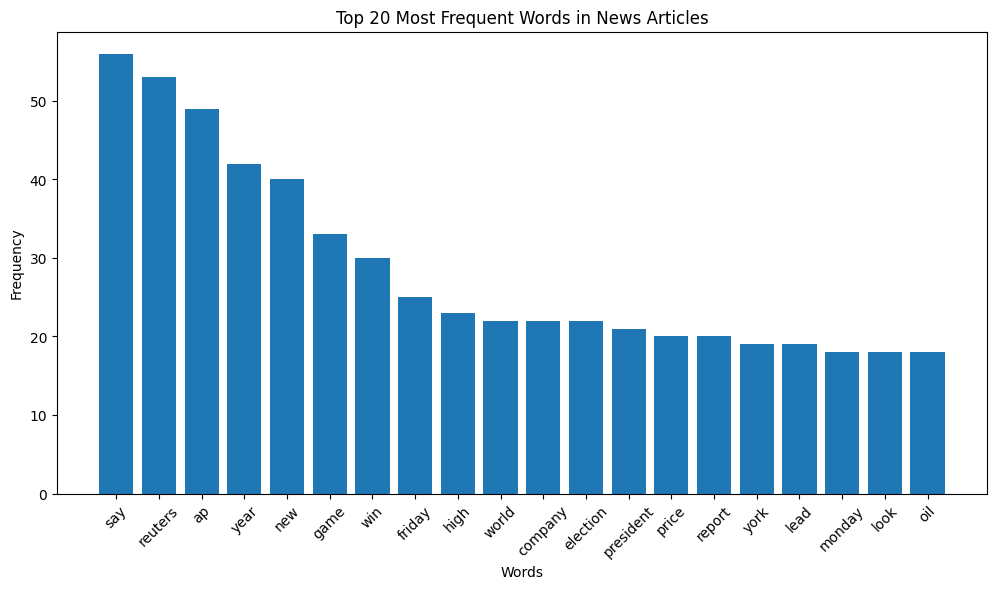

In [60]:
plt.figure(figsize=(12, 6))

plt.bar(word_df["Word"], word_df["Frequency"])

plt.title("Top 20 Most Frequent Words in News Articles")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

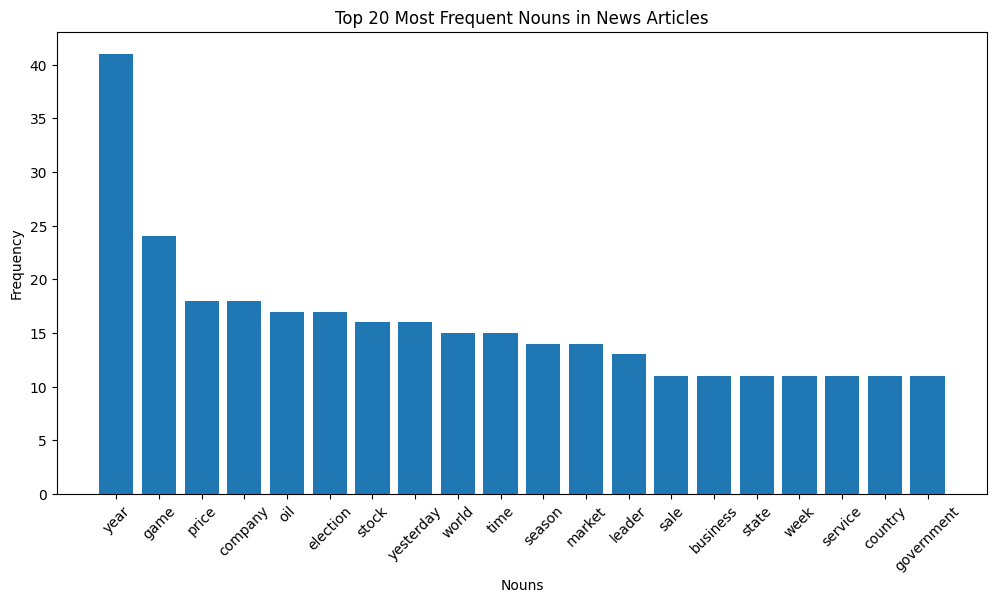

In [61]:
plt.figure(figsize=(12, 6))

plt.bar(noun_df["Noun"], noun_df["Frequency"])

plt.title("Top 20 Most Frequent Nouns in News Articles")
plt.xlabel("Nouns")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

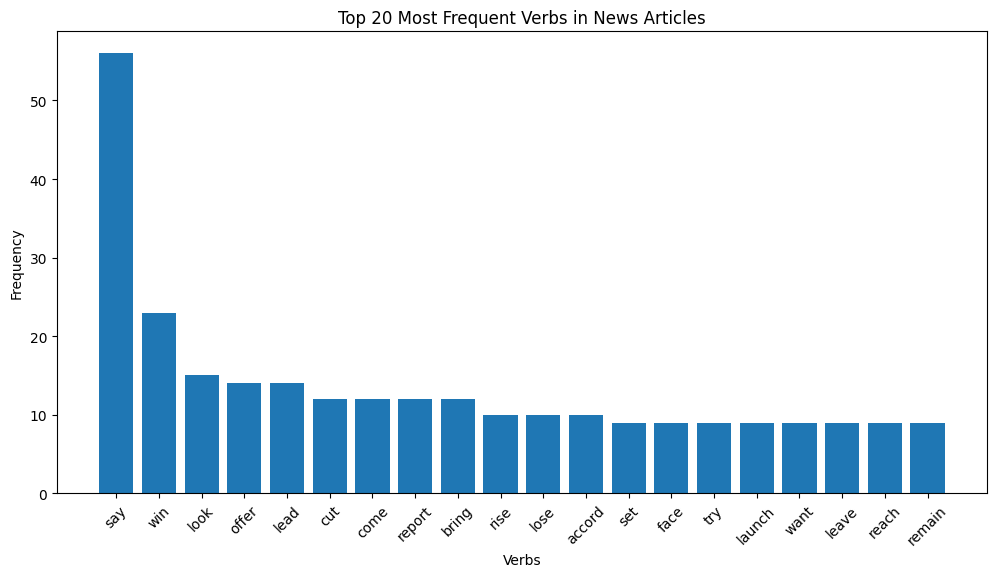

In [62]:
plt.figure(figsize=(12, 6))

plt.bar(verb_df["Verb"], verb_df["Frequency"])

plt.title("Top 20 Most Frequent Verbs in News Articles")
plt.xlabel("Verbs")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

## Summary Statistics

Summary statistics are used to describe the dataset and the results of preprocessing. These include the number of articles, total tokens, filtered tokens, nouns, verbs, and average tokens per article.

In [63]:
summary_stats = {
    "Number of Articles": len(sample_df),
    "Total Tokens": len(all_tokens),
    "Total Filtered Tokens": len(all_filtered_tokens),
    "Total Lemmas": len(all_lemmas),
    "Total Nouns": len(all_nouns),
    "Total Verbs": len(all_verbs),
    "Unique Lemmas": len(set(all_lemmas)),
    "Unique Nouns": len(set(all_nouns)),
    "Unique Verbs": len(set(all_verbs)),
    "Average Tokens per Article": round(len(all_tokens) / len(sample_df), 2),
    "Average Filtered Tokens per Article": round(len(all_filtered_tokens) / len(sample_df), 2)
}

summary_df = pd.DataFrame(summary_stats.items(), columns=["Statistic", "Value"])

summary_df

,Statistic,Value
0,Number of Articles,300.00
1,Total Tokens,13392.00
2,Total Filtered Tokens,6881.00
3,Total Lemmas,6881.00
4,Total Nouns,2478.00
5,Total Verbs,1178.00
6,Unique Lemmas,2902.00
7,Unique Nouns,1187.00
8,Unique Verbs,506.00
9,Average Tokens per Article,44.64


## Category Distribution

The dataset contains different categories of news articles. Checking the category distribution helps show whether the sample contains a balanced mix of topics.

In [64]:
category_counts = sample_df["category"].value_counts()

category_counts

,count
category,
Sports,88
Business,71
World,71
Sci/Tech,70


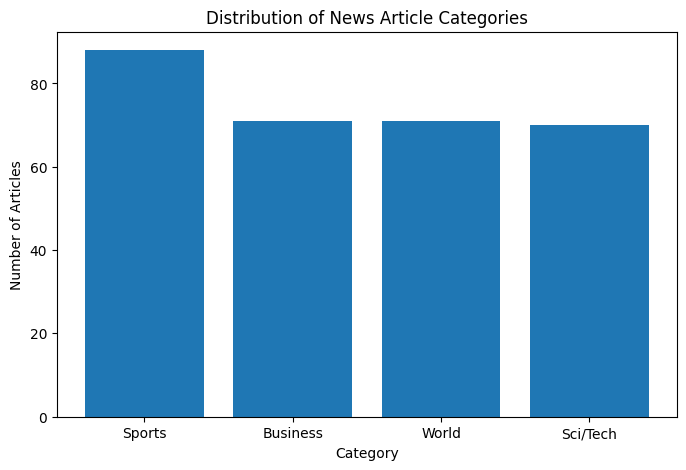

In [65]:
plt.figure(figsize=(8, 5))

plt.bar(category_counts.index, category_counts.values)

plt.title("Distribution of News Article Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")

plt.show()

## Part-of-Speech Tag Distribution

Part-of-speech tagging identifies the grammatical role of words in the articles. This analysis shows how often different types of words, such as nouns, verbs, adjectives, and adverbs, appear in the dataset.

In [66]:
pos_only = [pos for word, pos in all_pos_tags]

pos_counts = Counter(pos_only)

pos_df = pd.DataFrame(pos_counts.most_common(), columns=["POS Tag", "Frequency"])

pos_df

,POS Tag,Frequency
0,NOUN,2478
1,PROPN,2393
2,VERB,1178
3,ADJ,659
4,ADV,112
5,NUM,25
6,ADP,22
7,AUX,7
8,INTJ,3
9,CCONJ,2


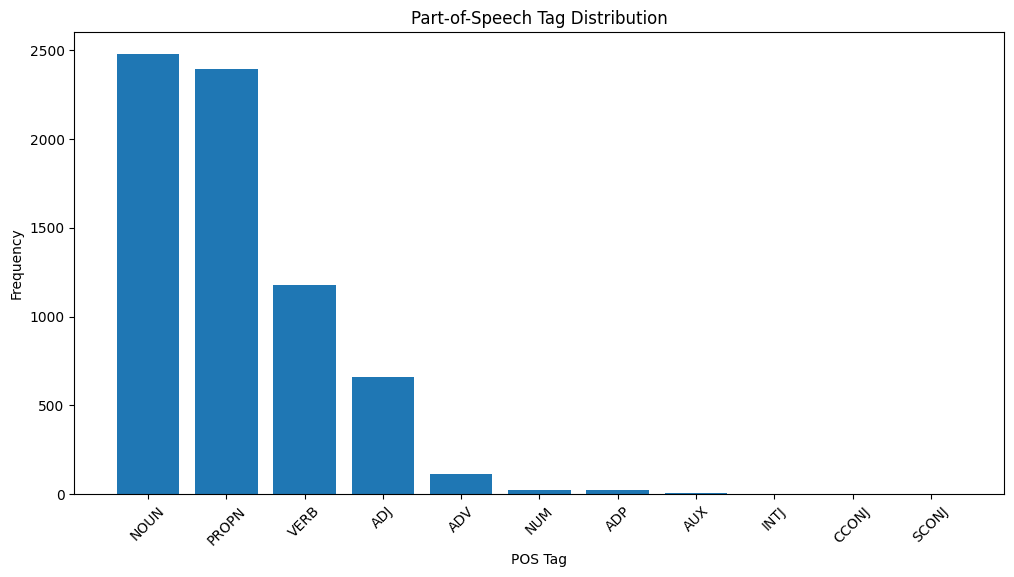

In [67]:
plt.figure(figsize=(12, 6))

plt.bar(pos_df["POS Tag"], pos_df["Frequency"])

plt.title("Part-of-Speech Tag Distribution")
plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

## Interpretation of Results

Based on the results, the most frequent words, nouns, and verbs show the common themes and actions found in the news articles. Frequent nouns usually represent the main topics, people, places, organizations, or issues discussed in the dataset. Frequent verbs show common actions or events reported in the articles.

The word frequency bar chart provides a visual summary of the most common words after preprocessing. The POS tag distribution also shows that nouns and verbs are important parts of the articles because news writing often focuses on events, people, places, and actions.

The summary statistics show the size of the processed data, including the number of tokens, filtered tokens, lemmas, nouns, and verbs. These results demonstrate how NLP preprocessing can transform raw news articles into structured information that can be analyzed.

## References

- spaCy. (n.d.). Industrial-strength Natural Language Processing in Python. https://spacy.io/
- Hugging Face. (n.d.). Datasets Library. https://huggingface.co/docs/datasets/
- AG News Dataset. Hugging Face Datasets. https://huggingface.co/datasets/ag_news